# Analisis Discriminante Cuadratico (QDA) - PYTHON
## Dataset: Anemia infantil - ENDES 2024 (RECH6)
**Universidad Nacional del Altiplano**

Estructura basada en el ejemplo de QDA visto en clase, aplicada al dataset de anemia, y usando las mismas variables que el analisis LDA para que ambos resultados sean comparables.

**Variable dependiente (Y):** grupo_anemia (Con_anemia / Sin_anemia) - Directriz OMS 2024 / RM 251-2024-MINSA

**Variables independientes (X):**
- edad_meses: Edad del nino en meses
- peso_kg: Peso en kilogramos
- talla_cm: Talla en centimetros
- talla_edad_z: Z-score Talla/Edad (OMS)
- peso_edad_z: Z-score Peso/Edad (OMS)


In [1]:
from google.colab import files
uploaded = files.upload()  # selecciona RECH6_2024.csv (archivo original, sin modificar)

Saving RECH6_2024.csv to RECH6_2024 (1).csv


In [2]:
!pip install scikit-learn scipy pandas matplotlib seaborn -q

## 0. Importaciones y configuracion inicial

Cargamos las librerias necesarias (pandas, numpy, scipy, sklearn, matplotlib, seaborn).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_curve, auc, ConfusionMatrixDisplay)

pd.set_option('display.width', 120)
np.random.seed(123)

## Paso 0.1: Preparacion del dataset desde el archivo crudo

Mismo criterio de limpieza usado en el LDA: se excluyen los codigos de 'no medido' del diccionario INEI (no se alteran datos reales) y se convierten las unidades. Asi, LDA y QDA son directamente comparables porque parten exactamente del mismo dataset.

In [4]:
# =====================================================================
# PASO 0.1: PREPARACION DEL DATASET (a partir del archivo crudo RECH6_2024.csv)
# =====================================================================

print("=" * 70)
print("PASO 0.1: PREPARACION DEL DATASET DESDE EL ARCHIVO CRUDO")
print("=" * 70)

df_crudo = pd.read_csv("RECH6_2024.csv", sep=";", low_memory=False)
print(f"\nDataset original (crudo): {df_crudo.shape}")

datos = df_crudo[['HC1', 'HC2', 'HC3', 'HC57A', 'HC70', 'HC71']].copy()
datos.columns = ['edad_meses', 'peso_kg_x10', 'talla_cm_x10', 'anemia_oms',
                  'talla_edad_z_x100', 'peso_edad_z_x100']

mask_validos = (
    (datos['peso_kg_x10'] < 999) &
    (datos['talla_cm_x10'] < 9999) &
    (datos['anemia_oms'].isin([1, 2, 3, 4])) &
    (datos['talla_edad_z_x100'].abs() < 9000) &
    (datos['peso_edad_z_x100'].abs() < 9000)
)
print(f"Filas excluidas por codigo de 'no medido': {(~mask_validos).sum()}")
print(f"Filas validas: {mask_validos.sum()} de {len(datos)}")

datos = datos[mask_validos].copy()
datos['peso_kg'] = datos['peso_kg_x10'] / 10
datos['talla_cm'] = datos['talla_cm_x10'] / 10
datos['talla_edad_z'] = datos['talla_edad_z_x100'] / 100
datos['peso_edad_z'] = datos['peso_edad_z_x100'] / 100
datos['grupo_anemia'] = np.where(datos['anemia_oms'] == 4, 'Sin_anemia', 'Con_anemia')

datos = datos[['edad_meses', 'peso_kg', 'talla_cm', 'talla_edad_z', 'peso_edad_z',
               'anemia_oms', 'grupo_anemia']].copy()

X_cols = ['edad_meses', 'peso_kg', 'talla_cm', 'talla_edad_z', 'peso_edad_z']
Y_col = 'grupo_anemia'
labels_clase = {'Sin_anemia': 'Sin anemia', 'Con_anemia': 'Con anemia'}
colores_clase = {'Sin_anemia': '#4C72B0', 'Con_anemia': '#DD8452'}

print(f"\nDataset final: {datos.shape}")
print(datos[Y_col].value_counts())

PASO 0.1: PREPARACION DEL DATASET DESDE EL ARCHIVO CRUDO

Dataset original (crudo): (20290, 43)
Filas excluidas por codigo de 'no medido': 1984
Filas validas: 18306 de 20290

Dataset final: (18306, 7)
grupo_anemia
Sin_anemia    12552
Con_anemia     5754
Name: count, dtype: int64


## 1. Carga y exploracion de datos

Revisamos tipos de datos, valores nulos, estadisticas descriptivas y la distribucion de la variable objetivo (grupo_anemia).


1. CARGA Y EXPLORACION DE DATOS

-- Tipos de datos --
edad_meses        int64
peso_kg         float64
talla_cm        float64
talla_edad_z    float64
peso_edad_z     float64
grupo_anemia     object
dtype: object

-- Valores nulos --
edad_meses      0
peso_kg         0
talla_cm        0
talla_edad_z    0
peso_edad_z     0
grupo_anemia    0
dtype: int64

-- Estadisticas descriptivas --
       edad_meses   peso_kg  talla_cm  talla_edad_z  peso_edad_z
count    18306.00  18306.00  18306.00      18306.00     18306.00
mean        32.53     13.27     88.89         -0.88        -0.14
std         15.60      3.46     11.82          1.01         1.04
min          6.00      4.90     55.20         -5.51        -4.54
25%         19.00     10.60     79.60         -1.55        -0.83
50%         33.00     13.10     89.90         -0.88        -0.18
75%         46.00     15.60     98.30         -0.20         0.49
max         59.00     31.90    119.00          3.54         4.43


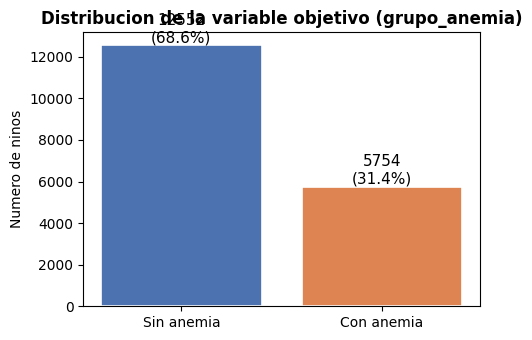

In [5]:
# =====================================================================
# 1. CARGA Y EXPLORACION DE DATOS
# =====================================================================
print("\n" + "=" * 70)
print("1. CARGA Y EXPLORACION DE DATOS")
print("=" * 70)

print("\n-- Tipos de datos --")
print(datos[X_cols + [Y_col]].dtypes)
print("\n-- Valores nulos --")
print(datos[X_cols + [Y_col]].isnull().sum())
print("\n-- Estadisticas descriptivas --")
print(datos[X_cols].describe().round(2))

# Distribucion de la variable objetivo Y
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = datos[Y_col].value_counts().reindex(['Sin_anemia', 'Con_anemia'])
bars = ax.bar(['Sin anemia', 'Con anemia'], counts.values,
               color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{v}\n({v/len(datos)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('Distribucion de la variable objetivo (grupo_anemia)', fontsize=12, fontweight='bold')
ax.set_ylabel('Numero de ninos')
plt.tight_layout()
plt.savefig('1_distribucion_Y.png', dpi=120)
plt.show()

## 2. Seleccion de predictores y visualizacion

Seleccionamos los 5 predictores cuantitativos y graficamos histogramas superpuestos y dispersion por pares para ver que tan separables son los grupos.


2. SELECCION DE PREDICTORES Y VISUALIZACION
Predictores seleccionados: ['edad_meses', 'peso_kg', 'talla_cm', 'talla_edad_z', 'peso_edad_z']
Variable objetivo: grupo_anemia
Clases: {'Sin_anemia': np.int64(12552), 'Con_anemia': np.int64(5754)}


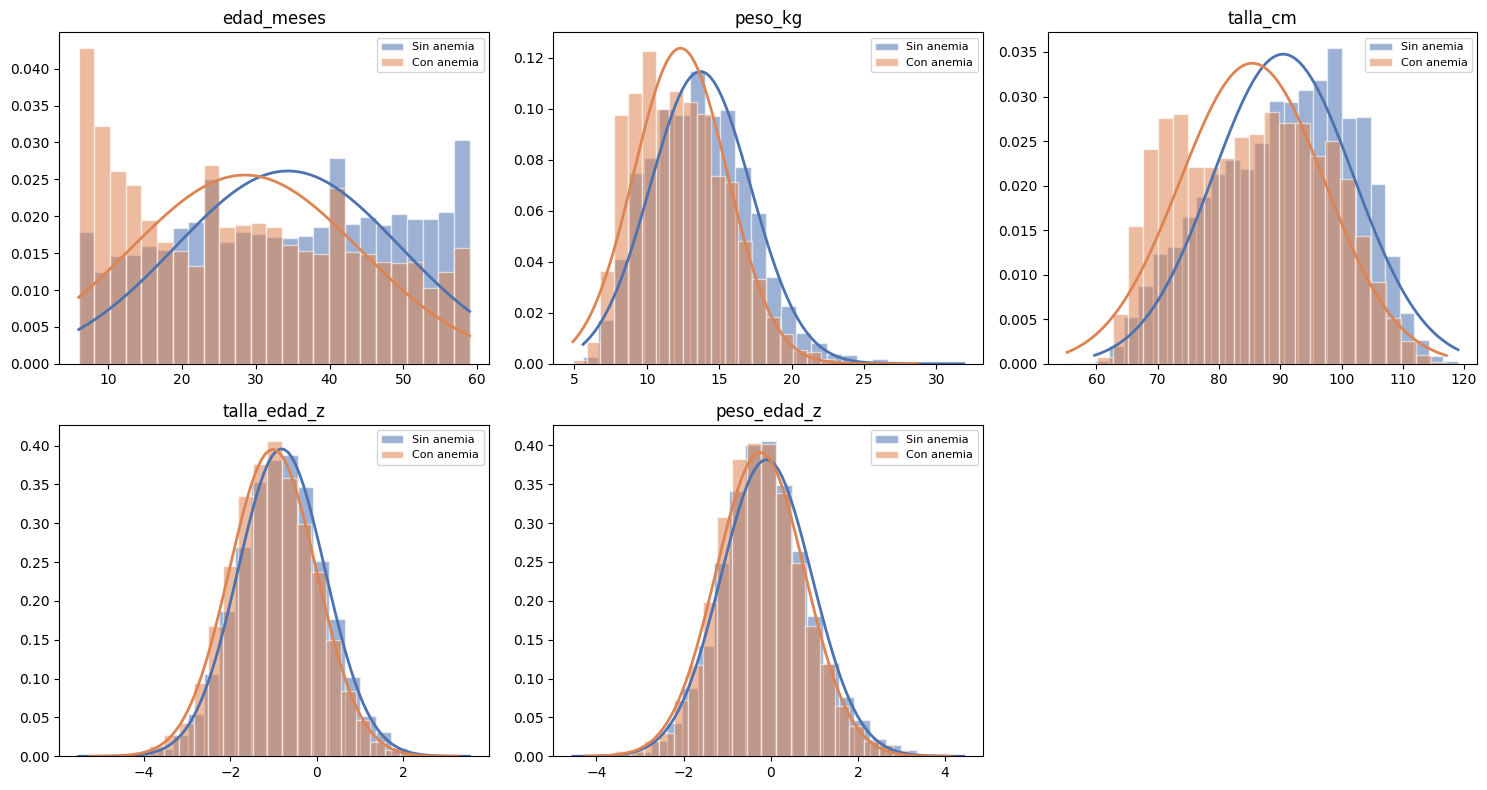

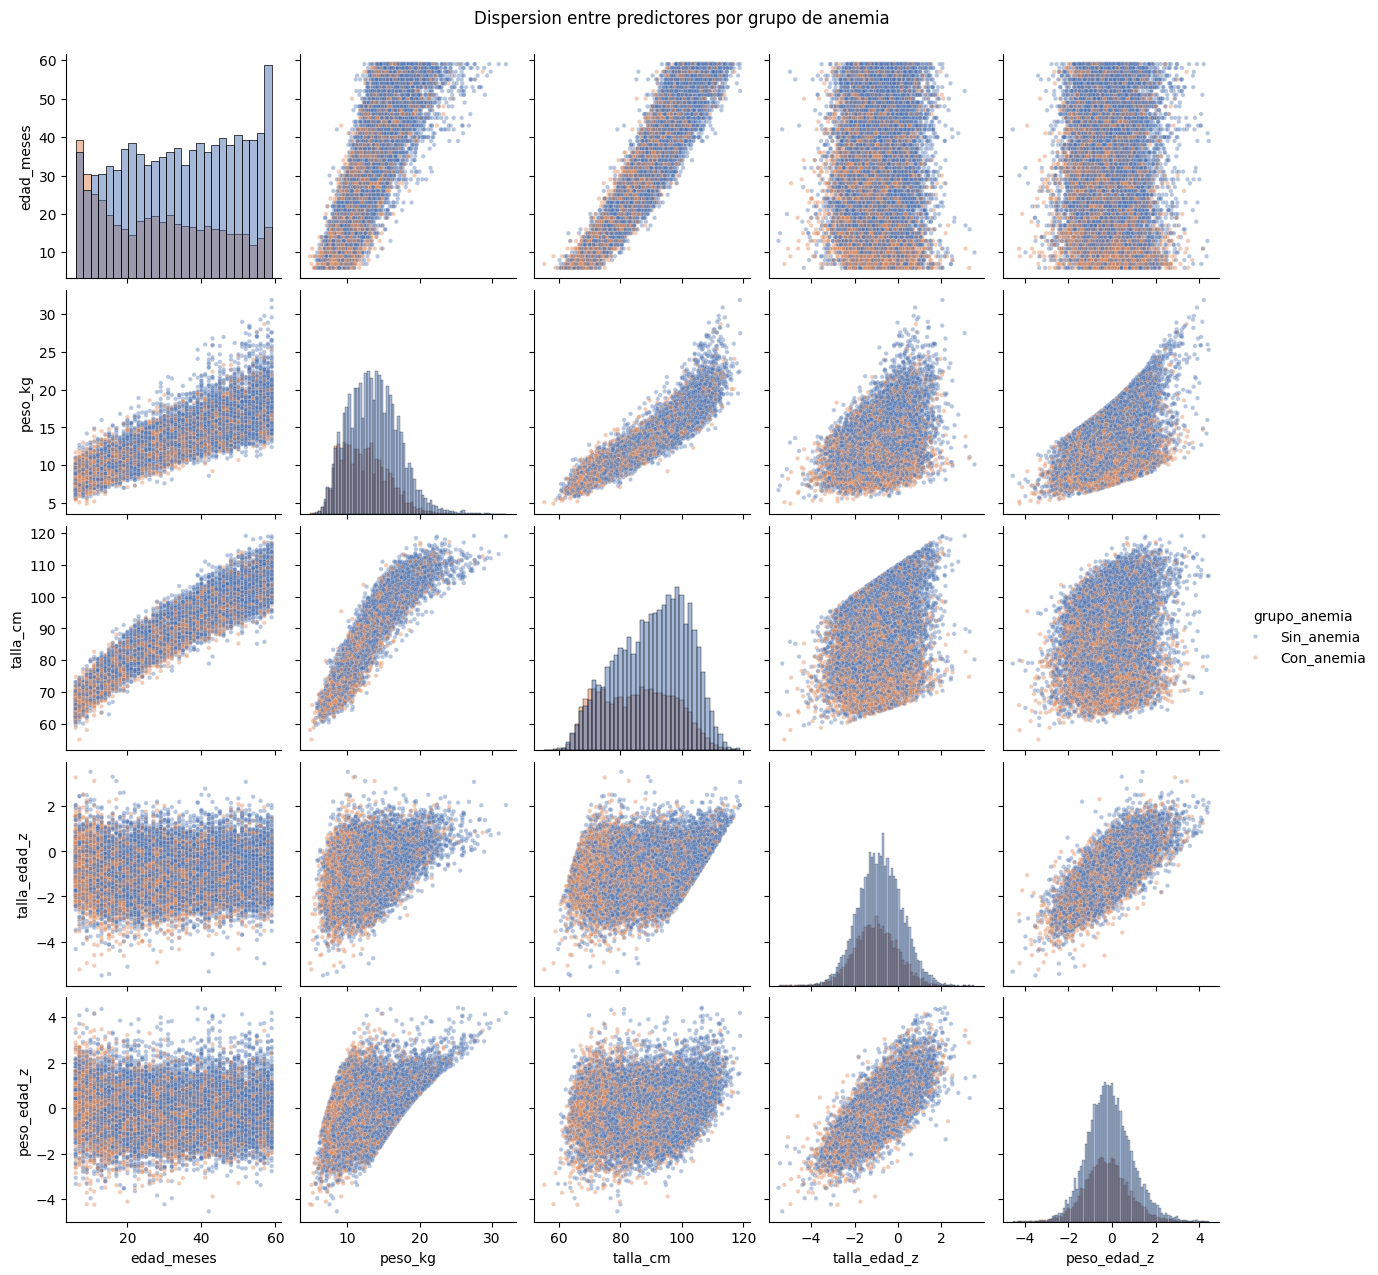

In [6]:
# =====================================================================
# 2. SELECCION DE PREDICTORES Y VISUALIZACION
# =====================================================================
print("\n" + "=" * 70)
print("2. SELECCION DE PREDICTORES Y VISUALIZACION")
print("=" * 70)

X = datos[X_cols].copy()
y = datos[Y_col].copy()

print("Predictores seleccionados:", X_cols)
print("Variable objetivo:", Y_col)
print("Clases:", dict(y.value_counts()))

# Histogramas superpuestos por clase
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(X_cols):
    ax = axes[i]
    for clase, nombre in labels_clase.items():
        datos_clase = X[y == clase][col]
        ax.hist(datos_clase, bins=25, alpha=0.55, color=colores_clase[clase],
                label=nombre, edgecolor='white', density=True)
        mu, sigma = datos_clase.mean(), datos_clase.std()
        x_curve = np.linspace(datos_clase.min(), datos_clase.max(), 100)
        ax.plot(x_curve, stats.norm.pdf(x_curve, mu, sigma), color=colores_clase[clase], lw=2)
    ax.set_title(col)
    ax.legend(fontsize=8)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('2_histogramas_predictores.png', dpi=120)
plt.show()

# Dispersión por pares
g = sns.pairplot(pd.concat([X, y], axis=1), hue=Y_col,
                  palette=colores_clase, diag_kind='hist',
                  plot_kws={'alpha': 0.4, 's': 10})
g.fig.suptitle("Dispersion entre predictores por grupo de anemia", y=1.02)
plt.savefig('3_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Supuesto de normalidad

Contrastamos la normalidad univariante (Shapiro-Wilk + QQ-plots) y multivariante (test de Mardia + distancia de Mahalanobis) de los predictores en cada grupo.


3. SUPUESTO DE NORMALIDAD

   TEST DE SHAPIRO-WILK - p-value por variable y clase
     Clase     Variable  Estadistico_W  p_value
Sin anemia   edad_meses        0.95451 0.000000
Sin anemia      peso_kg        0.98939 0.001115
Sin anemia     talla_cm        0.97531 0.000000
Sin anemia talla_edad_z        0.99590 0.219834
Sin anemia  peso_edad_z        0.98690 0.000182
Con anemia   edad_meses        0.93076 0.000000
Con anemia      peso_kg        0.96507 0.000000
Con anemia     talla_cm        0.96694 0.000000
Con anemia talla_edad_z        0.99480 0.089502
Con anemia  peso_edad_z        0.98152 0.000006

Nota: con N grande, Shapiro-Wilk tiende a rechazar Ho por desviaciones
minimas de la normalidad (se uso una submuestra de 500 por clase/variable).


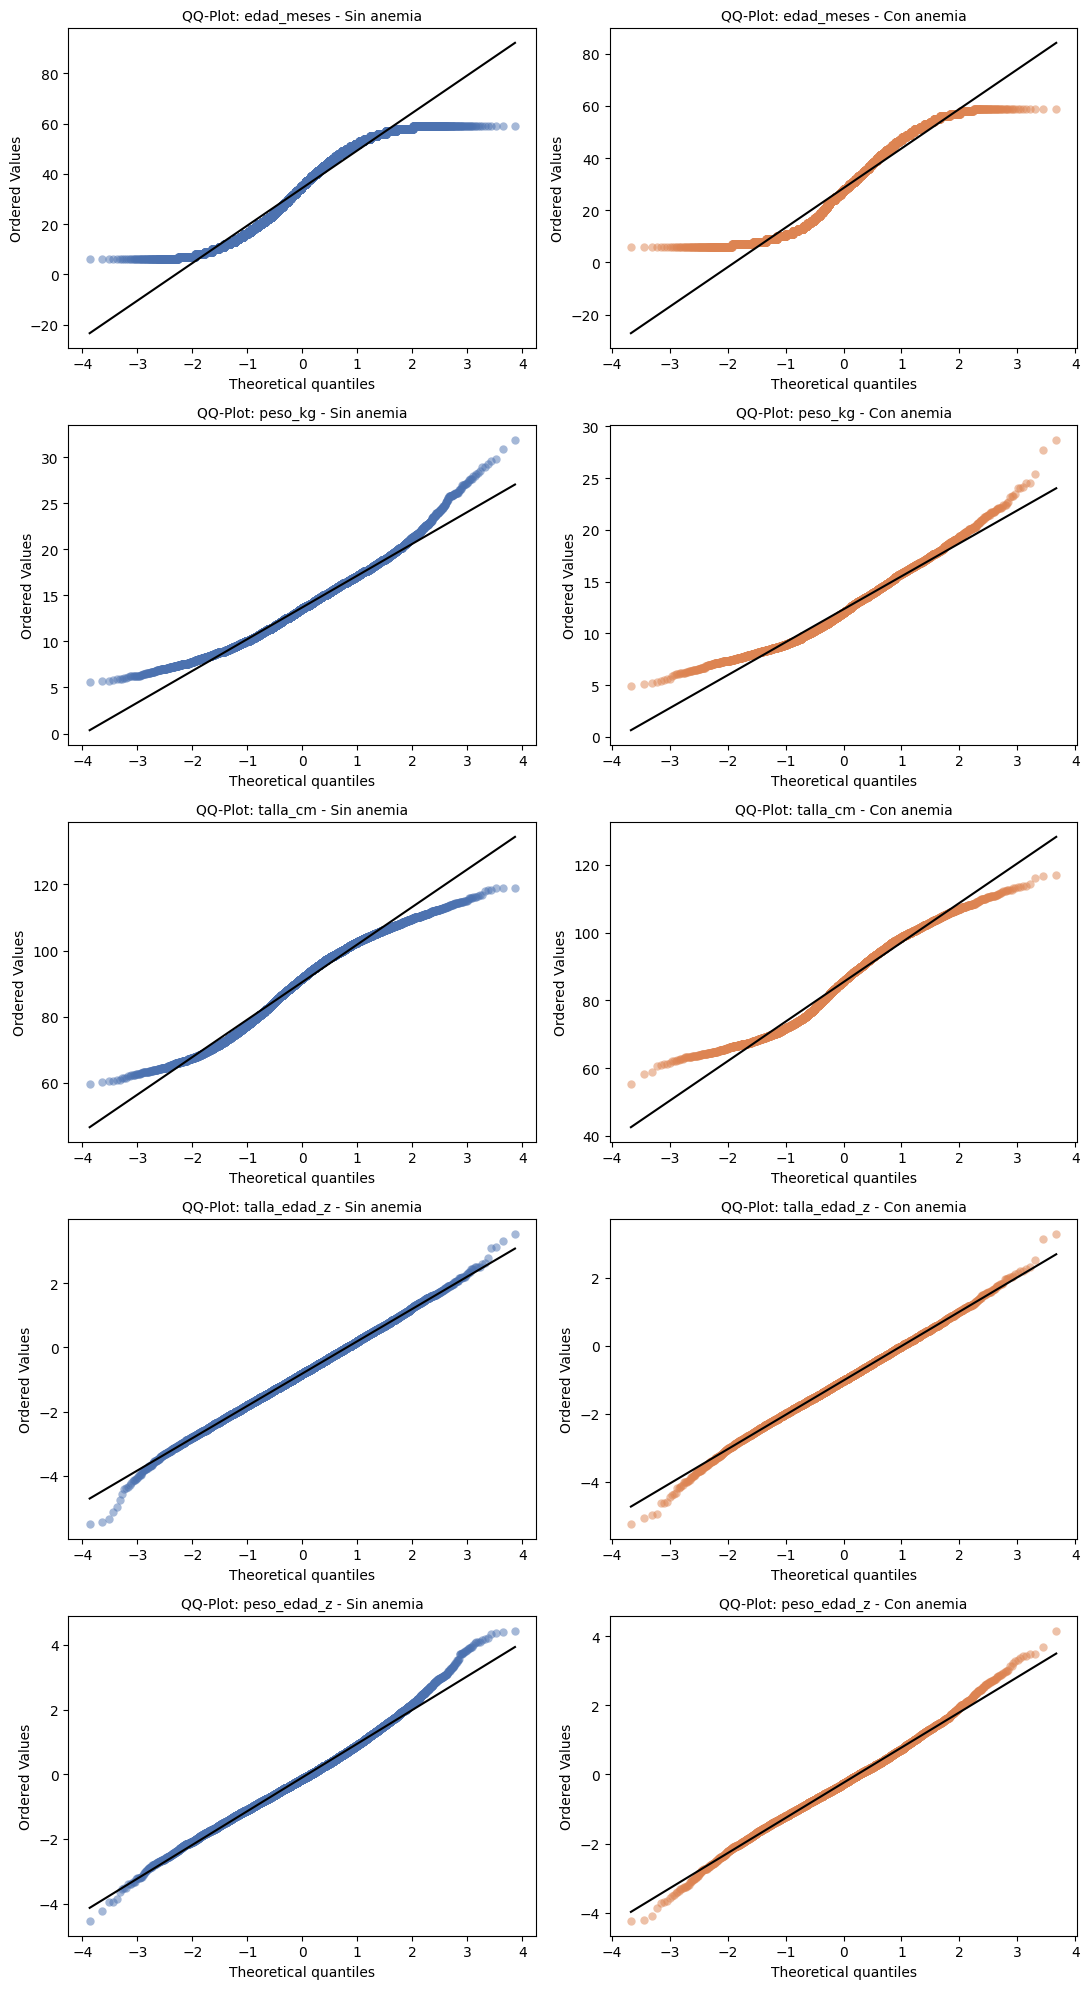


   NORMALIDAD MULTIVARIANTE - TEST DE MARDIA

Clase: Sin anemia (n=12552, submuestra=1500)
  Mardia Skewness : stat=5765.753  p-value=0.00000
  Mardia Kurtosis : stat=69.508  p-value=0.00000

Clase: Con anemia (n=5754, submuestra=1500)
  Mardia Skewness : stat=4922.943  p-value=0.00000
  Mardia Kurtosis : stat=80.886  p-value=0.00000


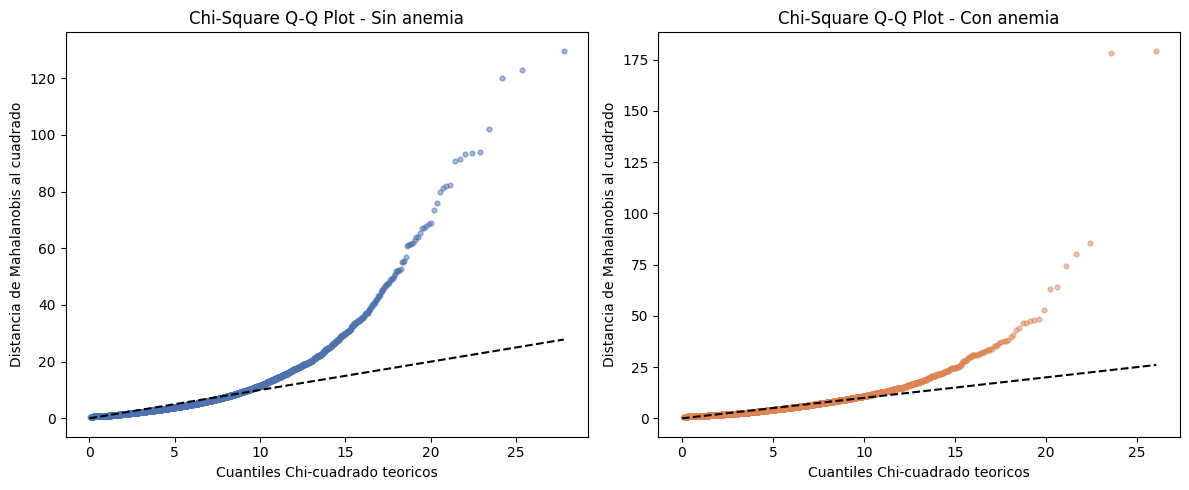

In [7]:
# =====================================================================
# 3. SUPUESTO DE NORMALIDAD
# =====================================================================
print("\n" + "=" * 70)
print("3. SUPUESTO DE NORMALIDAD")
print("=" * 70)

# --- Normalidad univariante: Shapiro-Wilk ---
print("\n" + "=" * 60)
print("   TEST DE SHAPIRO-WILK - p-value por variable y clase")
print("=" * 60)
resultados_sw = []
for clase, nombre in labels_clase.items():
    for col in X_cols:
        muestra = X[y == clase][col].dropna()
        if len(muestra) > 500:
            muestra = muestra.sample(500, random_state=1)
        stat, p = stats.shapiro(muestra)
        resultados_sw.append({'Clase': nombre, 'Variable': col,
                               'Estadistico_W': round(stat, 5),
                               'p_value': round(p, 6)})
df_sw = pd.DataFrame(resultados_sw)
print(df_sw.to_string(index=False))
print("\nNota: con N grande, Shapiro-Wilk tiende a rechazar Ho por desviaciones")
print("minimas de la normalidad (se uso una submuestra de 500 por clase/variable).")

# QQ-Plots por clase y predictor
fig, axes = plt.subplots(len(X_cols), 2, figsize=(11, 4 * len(X_cols)))
for i, col in enumerate(X_cols):
    for j, (clase, nombre) in enumerate(labels_clase.items()):
        ax = axes[i, j]
        muestra = X[y == clase][col].dropna()
        stats.probplot(muestra, dist='norm', plot=ax)
        ax.set_title(f'QQ-Plot: {col} - {nombre}', fontsize=10)
        ax.get_lines()[0].set(markerfacecolor=colores_clase[clase], markeredgecolor='none', alpha=0.5)
        ax.get_lines()[1].set(color='black')
plt.tight_layout()
plt.savefig('4_qqplots.png', dpi=120)
plt.show()

# --- Normalidad multivariante: Test de Mardia ---
print("\n" + "=" * 60)
print("   NORMALIDAD MULTIVARIANTE - TEST DE MARDIA")
print("=" * 60)

def mardia_test(Xm):
    n, p = Xm.shape
    Xc = Xm - Xm.mean(axis=0)
    S = np.cov(Xc, rowvar=False, bias=True)
    S_inv = np.linalg.inv(S)
    b1p = 0
    for i in range(n):
        for j in range(n):
            b1p += (Xc[i] @ S_inv @ Xc[j]) ** 3
    b1p /= n ** 2
    gl = p * (p + 1) * (p + 2) / 6
    stat_skew = n * b1p / 6
    p_skew = 1 - chi2.cdf(stat_skew, gl)
    b2p = np.mean([(Xc[i] @ S_inv @ Xc[i]) ** 2 for i in range(n)])
    stat_kurt = (b2p - p * (p + 2)) / np.sqrt(8 * p * (p + 2) / n)
    p_kurt = 2 * (1 - stats.norm.cdf(abs(stat_kurt)))
    return stat_skew, p_skew, stat_kurt, p_kurt

for clase, nombre in labels_clase.items():
    Xc = X[y == clase].values.astype(float)
    muestra_idx = np.random.choice(len(Xc), min(1500, len(Xc)), replace=False)
    Xc_sample = Xc[muestra_idx]
    sk_stat, sk_p, ku_stat, ku_p = mardia_test(Xc_sample)
    print(f"\nClase: {nombre} (n={len(Xc)}, submuestra={len(Xc_sample)})")
    print(f"  Mardia Skewness : stat={sk_stat:.3f}  p-value={sk_p:.5f}")
    print(f"  Mardia Kurtosis : stat={ku_stat:.3f}  p-value={ku_p:.5f}")

# --- Normalidad multivariante: distancia de Mahalanobis (chi-cuadrado QQ-plot) ---
def mahalanobis_distances(X_arr):
    mean_vec = np.mean(X_arr, axis=0)
    cov_mat = np.cov(X_arr, rowvar=False)
    inv_cov = np.linalg.pinv(cov_mat)
    diff = X_arr - mean_vec
    return np.array([d @ inv_cov @ d for d in diff])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, (clase, nombre) in enumerate(labels_clase.items()):
    Xc = X[y == clase].values.astype(float)
    dist_mah = mahalanobis_distances(Xc)
    p = Xc.shape[1]
    chi2_quantiles = chi2.ppf((np.arange(1, len(dist_mah) + 1) - 0.5) / len(dist_mah), p)
    dist_sorted = np.sort(dist_mah)
    axes[idx].scatter(chi2_quantiles, dist_sorted, s=12, alpha=0.5, color=colores_clase[clase])
    axes[idx].plot([0, chi2_quantiles.max()], [0, chi2_quantiles.max()], 'k--', lw=1.5)
    axes[idx].set_title(f'Chi-Square Q-Q Plot - {nombre}')
    axes[idx].set_xlabel('Cuantiles Chi-cuadrado teoricos')
    axes[idx].set_ylabel('Distancia de Mahalanobis al cuadrado')
plt.tight_layout()
plt.savefig('5_mahalanobis_qqplot.png', dpi=120)
plt.show()

## 4. Homogeneidad de matrices de covarianza (Test M de Box)

Test M de Box: contrasta si la matriz de covarianzas es igual entre grupos. Si se RECHAZA esta hipotesis (como suele pasar aqui), el QDA es mas apropiado que el LDA, ya que el QDA no asume covarianzas iguales.


4. HOMOGENEIDAD DE MATRICES DE COVARIANZA (TEST M DE BOX)
Ho: las matrices de covarianza son iguales entre grupos
(Si se rechaza Ho, el QDA es mas apropiado que el LDA)

Estadistico Chi-cuadrado (aprox.) = 2277.788
Grados de libertad = 15
p-value = 0.000000

-> Se RECHAZA Ho (p < 0.001, criterio conservador).
   Las matrices de covarianza NO son homogeneas -> EL QDA ES EL MODELO ADECUADO.


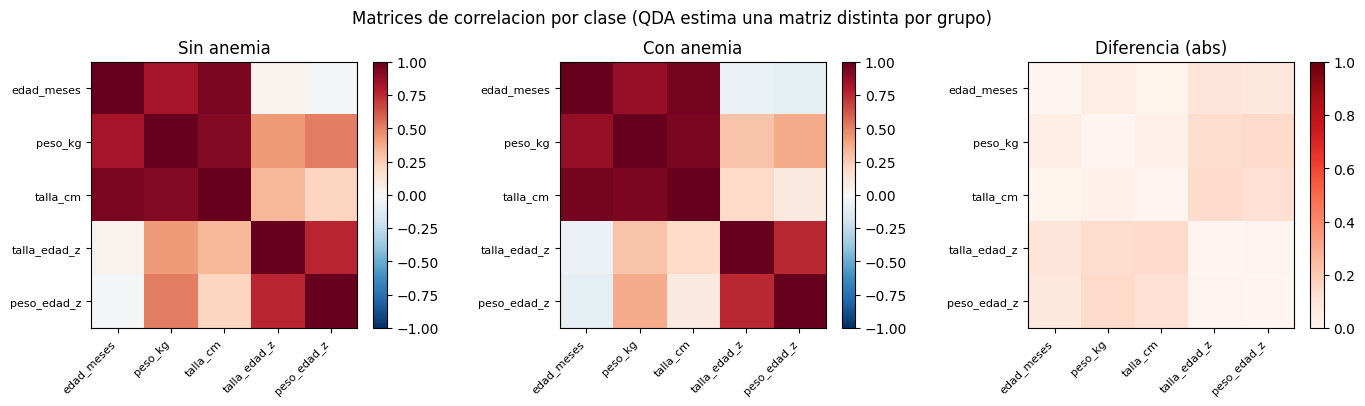

In [8]:
# =====================================================================
# 4. HOMOGENEIDAD DE MATRICES DE COVARIANZA (TEST M DE BOX)
# =====================================================================
print("\n" + "=" * 70)
print("4. HOMOGENEIDAD DE MATRICES DE COVARIANZA (TEST M DE BOX)")
print("=" * 70)
print("Ho: las matrices de covarianza son iguales entre grupos")
print("(Si se rechaza Ho, el QDA es mas apropiado que el LDA)\n")

def box_m_test(datos_df, X_cols, y_col):
    grupos = datos_df[y_col].unique()
    p = len(X_cols)
    n_total = len(datos_df)
    g = len(grupos)
    S_list, n_list = [], []
    S_pooled = np.zeros((p, p))
    for grp in grupos:
        Xg = datos_df[datos_df[y_col] == grp][X_cols].values
        ng = Xg.shape[0]
        Sg = np.cov(Xg, rowvar=False)
        S_list.append(Sg)
        n_list.append(ng)
        S_pooled += (ng - 1) * Sg
    S_pooled = S_pooled / (n_total - g)
    log_det_pooled = np.linalg.slogdet(S_pooled)[1]
    M = (n_total - g) * log_det_pooled
    for ng, Sg in zip(n_list, S_list):
        M -= (ng - 1) * np.linalg.slogdet(Sg)[1]
    c1 = sum(1 / (ng - 1) for ng in n_list) - 1 / (n_total - g)
    c1 = c1 * (2 * p ** 2 + 3 * p - 1) / (6 * (p + 1) * (g - 1))
    chi2_stat = M * (1 - c1)
    gl = 0.5 * p * (p + 1) * (g - 1)
    p_value = 1 - chi2.cdf(chi2_stat, gl)
    return chi2_stat, gl, p_value, S_list, grupos

chi2_stat, gl, p_value_box, S_list, grupos_box = box_m_test(datos, X_cols, Y_col)
print(f"Estadistico Chi-cuadrado (aprox.) = {chi2_stat:.3f}")
print(f"Grados de libertad = {gl:.0f}")
print(f"p-value = {p_value_box:.6f}")
if p_value_box < 0.001:
    print("\n-> Se RECHAZA Ho (p < 0.001, criterio conservador).")
    print("   Las matrices de covarianza NO son homogeneas -> EL QDA ES EL MODELO ADECUADO.")
else:
    print("\n-> No se rechaza Ho. Las matrices son homogeneas -> LDA seria suficiente.")

# Visualizacion de matrices de correlacion por clase
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['Sin anemia', 'Con anemia', 'Diferencia (abs)']
covs = []
for idx, clase in enumerate(['Sin_anemia', 'Con_anemia']):
    Xc = X[y == clase].values.astype(float)
    cov_c = np.corrcoef(Xc, rowvar=False)
    covs.append(cov_c)
    im = axes[idx].imshow(cov_c, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[idx].set_xticks(range(len(X_cols)))
    axes[idx].set_xticklabels(X_cols, rotation=45, ha='right', fontsize=8)
    axes[idx].set_yticks(range(len(X_cols)))
    axes[idx].set_yticklabels(X_cols, fontsize=8)
    axes[idx].set_title(titles[idx])
    plt.colorbar(im, ax=axes[idx], fraction=0.046)
diff_cov = np.abs(covs[0] - covs[1])
im = axes[2].imshow(diff_cov, cmap='Reds', vmin=0, vmax=1)
axes[2].set_xticks(range(len(X_cols)))
axes[2].set_xticklabels(X_cols, rotation=45, ha='right', fontsize=8)
axes[2].set_yticks(range(len(X_cols)))
axes[2].set_yticklabels(X_cols, fontsize=8)
axes[2].set_title(titles[2])
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.suptitle("Matrices de correlacion por clase (QDA estima una matriz distinta por grupo)")
plt.tight_layout()
plt.savefig('6_matrices_correlacion.png', dpi=120)
plt.show()

## 5. Ajuste del modelo QDA

Entrenamos el modelo QDA (70% train / 30% test) y mostramos las probabilidades previas, las medias por grupo y las matrices de covarianza estimadas para cada clase (la clave que distingue QDA de LDA).

In [9]:
# =====================================================================
# 5. AJUSTE DEL MODELO QDA
# =====================================================================
print("\n" + "=" * 70)
print("5. AJUSTE DEL MODELO QDA")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

modelo_qda = QuadraticDiscriminantAnalysis(store_covariance=True)
modelo_qda.fit(X_train, y_train)

print("\n" + "=" * 55)
print("   MODELO QDA - Parametros estimados")
print("=" * 55)
print("\nProbabilidades previas (priors):")
for clase, prior in zip(modelo_qda.classes_, modelo_qda.priors_):
    print(f"  {clase}: {prior:.4f}")

print("\nMedias por grupo:")
medias_qda = pd.DataFrame(modelo_qda.means_, columns=X_cols, index=modelo_qda.classes_)
print(medias_qda.round(3))

print("\nMatrices de covarianza por clase (QDA estima una por cada grupo):")
for clase, cov in zip(modelo_qda.classes_, modelo_qda.covariance_):
    print(f"\n--- Covarianza: {clase} ---")
    print(pd.DataFrame(cov, columns=X_cols, index=X_cols).round(3))


5. AJUSTE DEL MODELO QDA
Train: 12814 | Test: 5492

   MODELO QDA - Parametros estimados

Probabilidades previas (priors):
  Con_anemia: 0.3143
  Sin_anemia: 0.6857

Medias por grupo:
            edad_meses  peso_kg  talla_cm  talla_edad_z  peso_edad_z
Con_anemia      28.614   12.338    85.471        -1.015       -0.245
Sin_anemia      34.361   13.694    90.466        -0.822       -0.107

Matrices de covarianza por clase (QDA estima una por cada grupo):

--- Covarianza: Con_anemia ---
              edad_meses  peso_kg  talla_cm  talla_edad_z  peso_edad_z
edad_meses       244.962   44.277   177.680        -0.773       -1.380
peso_kg           44.277   10.518    36.270         0.970        1.226
talla_cm         177.680   36.270   141.847         2.484        1.294
talla_edad_z      -0.773    0.970     2.484         1.026        0.773
peso_edad_z       -1.380    1.226     1.294         0.773        1.027

--- Covarianza: Sin_anemia ---
              edad_meses  peso_kg  talla_cm  talla_

## 6. Evaluacion del modelo: matriz de confusion y metricas

Calculamos accuracy, error de clasificacion, matriz de confusion, reporte de clasificacion y la curva ROC con su AUC para el modelo QDA sobre el conjunto de prueba.


6. EVALUACION DEL MODELO: MATRIZ DE CONFUSION Y METRICAS
Training error : 32.67%   |   Training accuracy : 67.33%
Test error     : 32.72%   |   Test accuracy     : 67.28%

Matriz de confusion (test):
                 Pred_Con_anemia  Pred_Sin_anemia
Real_Con_anemia              517             1209
Real_Sin_anemia              588             3178

Reporte de clasificacion:
              precision    recall  f1-score   support

  Con_anemia       0.47      0.30      0.37      1726
  Sin_anemia       0.72      0.84      0.78      3766

    accuracy                           0.67      5492
   macro avg       0.60      0.57      0.57      5492
weighted avg       0.64      0.67      0.65      5492



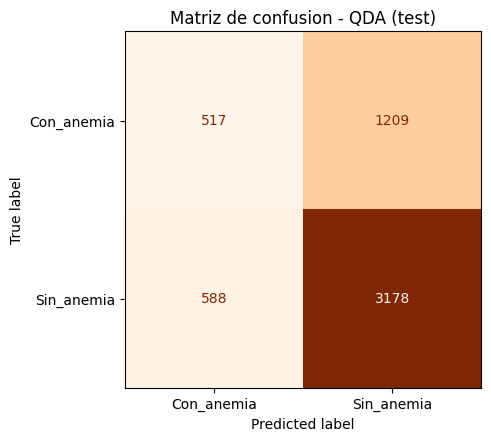

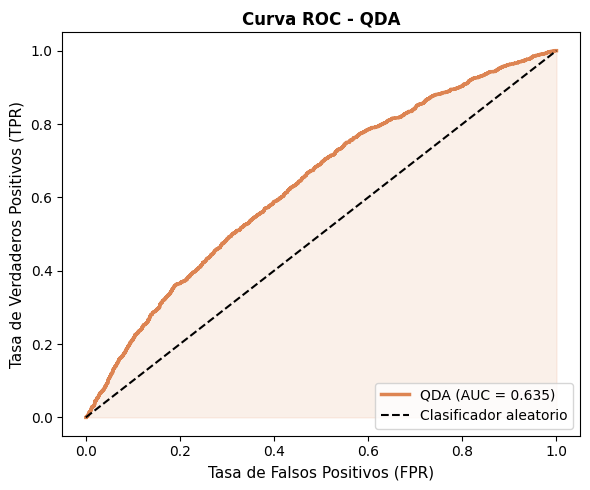


AUC (QDA) = 0.6350


In [10]:
# =====================================================================
# 6. EVALUACION DEL MODELO: MATRIZ DE CONFUSION Y METRICAS
# =====================================================================
print("\n" + "=" * 70)
print("6. EVALUACION DEL MODELO: MATRIZ DE CONFUSION Y METRICAS")
print("=" * 70)

y_pred_train = modelo_qda.predict(X_train)
y_pred_test = modelo_qda.predict(X_test)
y_prob_test = modelo_qda.predict_proba(X_test)[:, list(modelo_qda.classes_).index('Con_anemia')]

train_error = (y_train != y_pred_train).mean() * 100
test_error = (y_test != y_pred_test).mean() * 100
train_acc = 100 - train_error
test_acc = 100 - test_error

print(f"Training error : {train_error:.2f}%   |   Training accuracy : {train_acc:.2f}%")
print(f"Test error     : {test_error:.2f}%   |   Test accuracy     : {test_acc:.2f}%")

print("\nMatriz de confusion (test):")
cm = confusion_matrix(y_test, y_pred_test, labels=modelo_qda.classes_)
print(pd.DataFrame(cm, index=[f"Real_{c}" for c in modelo_qda.classes_],
                    columns=[f"Pred_{c}" for c in modelo_qda.classes_]))

print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred_test, target_names=modelo_qda.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_qda.classes_)
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title("Matriz de confusion - QDA (test)")
plt.tight_layout()
plt.savefig('7_matriz_confusion_qda.png', dpi=120)
plt.show()

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob_test, pos_label='Con_anemia')
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#DD8452', lw=2.5, label=f'QDA (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador aleatorio')
ax.fill_between(fpr, tpr, alpha=0.12, color='#DD8452')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC - QDA', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('8_curva_roc_qda.png', dpi=120)
plt.show()
print(f"\nAUC (QDA) = {roc_auc:.4f}")

## 7. Espacio de decision (Partition Plot - pares de predictores)

Visualizamos las fronteras de decision (curvas, no rectas) del QDA para distintos pares de predictores, equivalente a partimat() en R.


7. ESPACIO DE DECISION (equivalente a partimat() de R)


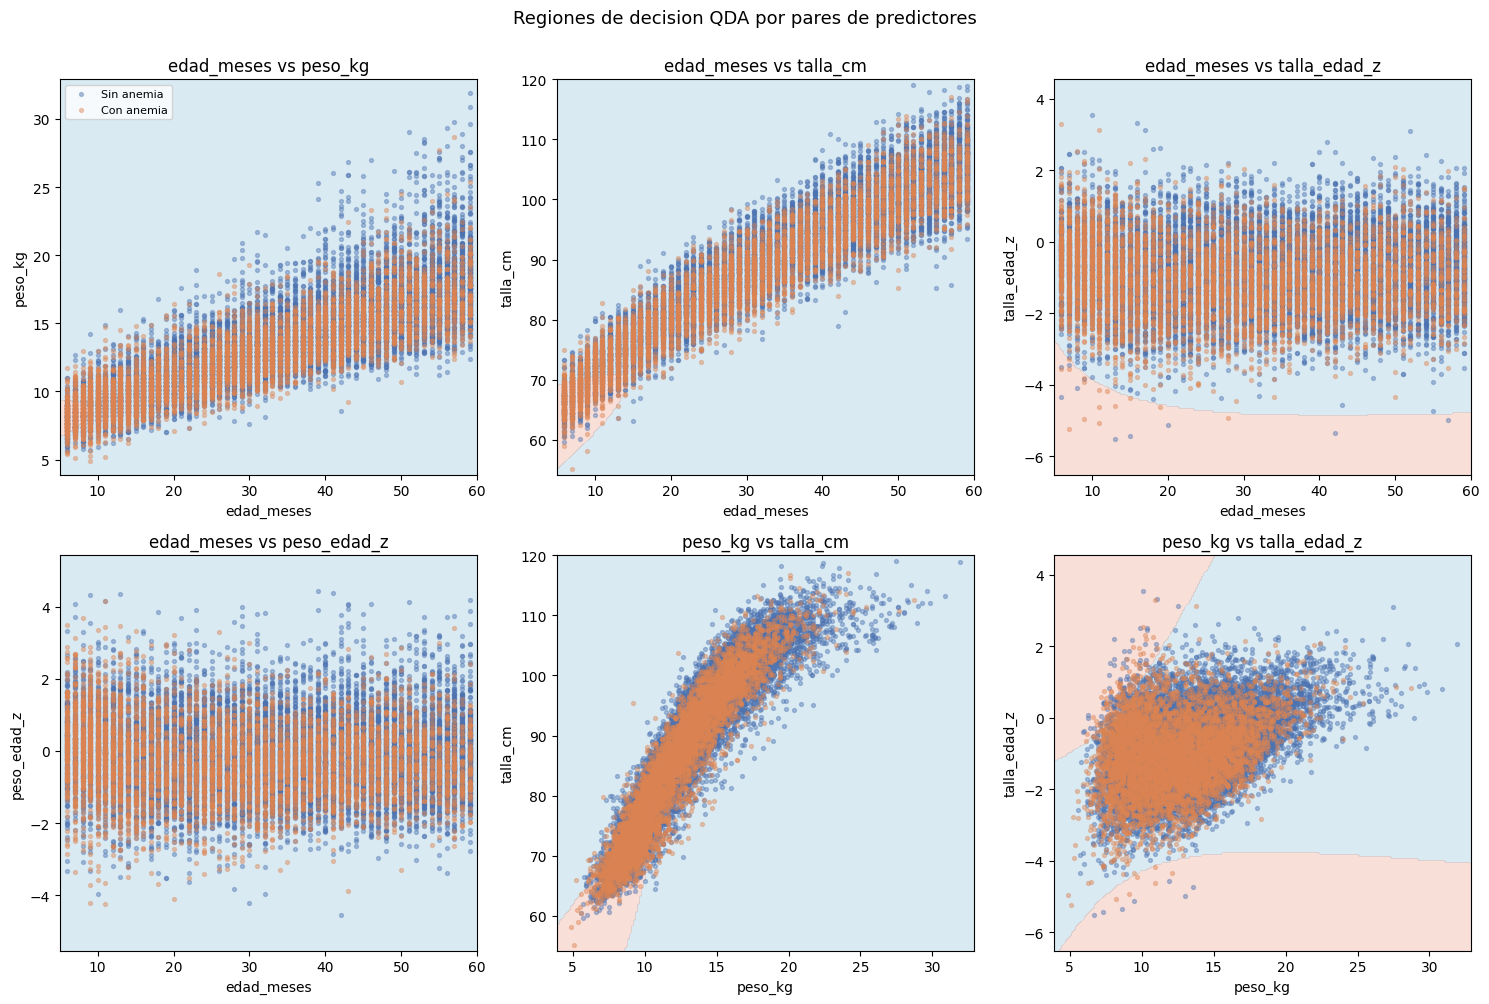

In [11]:
# =====================================================================
# 7. ESPACIO DE DECISION (PARTITION PLOT - PARES DE PREDICTORES)
# =====================================================================
print("\n" + "=" * 70)
print("7. ESPACIO DE DECISION (equivalente a partimat() de R)")
print("=" * 70)

from itertools import combinations

pares = list(combinations(range(len(X_cols)), 2))[:6]
ncols = 3
nrows = (len(pares) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for idx, (i1, i2) in enumerate(pares):
    ax = axes[idx]
    col1, col2 = X_cols[i1], X_cols[i2]
    X2 = X[[col1, col2]].values
    qda2 = QuadraticDiscriminantAnalysis()
    qda2.fit(X2, y)

    x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
    y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = qda2.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z == 'Con_anemia').astype(int).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu_r', levels=1)
    for clase, nombre in labels_clase.items():
        mask = y == clase
        ax.scatter(X2[mask, 0], X2[mask, 1], s=8, alpha=0.4,
                   color=colores_clase[clase], label=nombre)
    ax.set_xlabel(col1)
    ax.set_ylabel(col2)
    ax.set_title(f'{col1} vs {col2}')
    if idx == 0:
        ax.legend(fontsize=8)

for j in range(len(pares), len(axes)):
    axes[j].axis('off')

plt.suptitle("Regiones de decision QDA por pares de predictores", y=1.0, fontsize=13)
plt.tight_layout()
plt.savefig('9_partition_plot.png', dpi=120)
plt.show()

## 8. Comparacion QDA vs LDA

Comparamos directamente QDA contra LDA en el mismo conjunto de prueba: error de clasificacion, accuracy y AUC de ambos modelos.


8. COMPARACION QDA vs LDA
   COMPARACION QDA vs LDA - Conjunto de Test
  QDA - Error: 32.72%  |  Accuracy: 67.28%  |  AUC: 0.6350
  LDA - Error: 31.32%  |  Accuracy: 68.68%  |  AUC: 0.6293


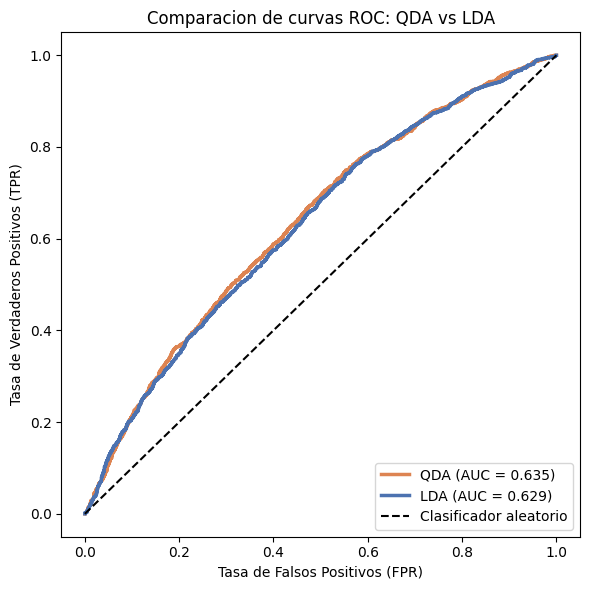

In [12]:
# =====================================================================
# 8. COMPARACION QDA vs LDA
# =====================================================================
print("\n" + "=" * 70)
print("8. COMPARACION QDA vs LDA")
print("=" * 70)

modelo_lda = LinearDiscriminantAnalysis()
modelo_lda.fit(X_train, y_train)

y_pred_lda = modelo_lda.predict(X_test)
y_prob_lda = modelo_lda.predict_proba(X_test)[:, list(modelo_lda.classes_).index('Con_anemia')]

err_lda = (y_test != y_pred_lda).mean() * 100
err_qda = test_error

fpr_lda, tpr_lda, _ = roc_curve(y_test, y_prob_lda, pos_label='Con_anemia')
auc_lda = auc(fpr_lda, tpr_lda)

print("=" * 50)
print("   COMPARACION QDA vs LDA - Conjunto de Test")
print("=" * 50)
print(f"  QDA - Error: {err_qda:.2f}%  |  Accuracy: {100-err_qda:.2f}%  |  AUC: {roc_auc:.4f}")
print(f"  LDA - Error: {err_lda:.2f}%  |  Accuracy: {100-err_lda:.2f}%  |  AUC: {auc_lda:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='#DD8452', lw=2.5, label=f'QDA (AUC = {roc_auc:.3f})')
ax.plot(fpr_lda, tpr_lda, color='#4C72B0', lw=2.5, label=f'LDA (AUC = {auc_lda:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Comparacion de curvas ROC: QDA vs LDA')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('10_roc_qda_vs_lda.png', dpi=120)
plt.show()

## 9. Validacion cruzada (k-Fold Cross Validation)

Validacion cruzada 10-fold para QDA y LDA, de modo que la comparacion no dependa de una sola particion train/test.

In [13]:
# =====================================================================
# 9. VALIDACION CRUZADA (K-FOLD CROSS VALIDATION)
# =====================================================================
print("\n" + "=" * 70)
print("9. VALIDACION CRUZADA (10-FOLD)")
print("=" * 70)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

scores_qda = cross_val_score(QuadraticDiscriminantAnalysis(), X, y, cv=cv, scoring='accuracy')
scores_lda = cross_val_score(LinearDiscriminantAnalysis(), X, y, cv=cv, scoring='accuracy')

print("=" * 55)
print("   VALIDACION CRUZADA 10-Fold")
print("=" * 55)
print(f"  QDA - Accuracy media: {scores_qda.mean()*100:.2f}% (+/- {scores_qda.std()*100:.2f}%)")
print(f"  LDA - Accuracy media: {scores_lda.mean()*100:.2f}% (+/- {scores_lda.std()*100:.2f}%)")


9. VALIDACION CRUZADA (10-FOLD)
   VALIDACION CRUZADA 10-Fold
  QDA - Accuracy media: 67.17% (+/- 0.73%)
  LDA - Accuracy media: 68.58% (+/- 0.23%)


## 10. Prediccion para un nuevo caso

Clasificamos un nuevo caso hipotetico (un nino con ciertas medidas) usando el modelo QDA ya entrenado.

In [14]:
# =====================================================================
# 10. PREDICCION PARA UN NUEVO CASO
# =====================================================================
print("\n" + "=" * 70)
print("10. PREDICCION PARA UN NUEVO CASO")
print("=" * 70)

nuevo_caso = pd.DataFrame({
    'edad_meses': [24],
    'peso_kg': [11.5],
    'talla_cm': [84],
    'talla_edad_z': [-1.2],
    'peso_edad_z': [-0.8]
})
print("Nuevo caso a clasificar:")
print(nuevo_caso)

pred_qda_nuevo = modelo_qda.predict(nuevo_caso[X_cols])[0]
prob_qda_nuevo = modelo_qda.predict_proba(nuevo_caso[X_cols])[0]
print(f"\nQDA -> Clase predicha: {pred_qda_nuevo}")
print(f"QDA -> Probabilidades: {dict(zip(modelo_qda.classes_, prob_qda_nuevo.round(4)))}")


10. PREDICCION PARA UN NUEVO CASO
Nuevo caso a clasificar:
   edad_meses  peso_kg  talla_cm  talla_edad_z  peso_edad_z
0          24     11.5        84          -1.2         -0.8

QDA -> Clase predicha: Sin_anemia
QDA -> Probabilidades: {'Con_anemia': np.float64(0.406), 'Sin_anemia': np.float64(0.594)}


## Guardar tabla de resultados

Guardamos un CSV con las predicciones de clase y probabilidad posterior del QDA para todas las observaciones del dataset.

In [15]:
# =====================================================================
# GUARDAR TABLA DE RESULTADOS
# =====================================================================
print("\n" + "=" * 70)
print("GUARDANDO RESULTADOS")
print("=" * 70)

pred_total = modelo_qda.predict(X)
proba_total = modelo_qda.predict_proba(X)
resultado = datos[X_cols + [Y_col]].copy()
resultado['pred_QDA'] = pred_total
resultado['prob_Con_anemia_QDA'] = proba_total[:, list(modelo_qda.classes_).index('Con_anemia')]
resultado.to_csv('tabla_predicciones_anemia_QDA.csv', index=False)
print("Archivo guardado: tabla_predicciones_anemia_QDA.csv")

print("\n" + "=" * 70)
print("ANALISIS QDA COMPLETO")
print("=" * 70)


GUARDANDO RESULTADOS
Archivo guardado: tabla_predicciones_anemia_QDA.csv

ANALISIS QDA COMPLETO
